In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Decision Tree Classification

## Mô tả

Decision Tree Classification là một thuật toán học máy dùng để phân loại dữ liệu. Nó phân chia không gian đặc trưng thành các vùng dựa trên các giá trị ngưỡng của đặc trưng, sau đó gán nhãn cho mỗi vùng dựa trên các giá trị đầu ra trong tập huấn luyện. Cây quyết định dễ hiểu, trực quan và có thể giải thích được các quyết định phân loại.

## Cách hoạt động

Quá trình xây dựng cây quyết định phân loại bao gồm các bước chính sau:

1. **Chọn đặc trưng và giá trị ngưỡng để chia dữ liệu**:
   - Chọn đặc trưng và giá trị ngưỡng sao cho chia dữ liệu thành hai tập con với độ thuần khiết (purity) cao nhất.
   - Các chỉ số đo độ thuần khiết thường được sử dụng là Gini impurity và Entropy (Information Gain).

2. **Chia dữ liệu**:
   - Chia dữ liệu thành hai tập con dựa trên giá trị ngưỡng đã chọn.

3. **Lặp lại quá trình**:
   - Lặp lại quá trình chia dữ liệu cho đến khi đạt điều kiện dừng, chẳng hạn như:
     - Độ sâu của cây đạt mức tối đa.
     - Số lượng mẫu trong một nút nhỏ hơn giá trị tối thiểu.
     - Tất cả các mẫu trong một nút có cùng nhãn.

4. **Gán nhãn cho các nút lá**:
   - Nhãn của một nút lá được xác định bằng cách gán nhãn phổ biến nhất (majority label) trong tập con tương ứng.

## Ưu điểm và nhược điểm

### Ưu điểm:
- **Dễ hiểu và trực quan**: Cây quyết định dễ hiểu và có thể được trực quan hóa để giải thích các quyết định phân loại.
- **Không cần chuẩn hóa dữ liệu**: Decision Tree Classification không yêu cầu chuẩn hóa dữ liệu hoặc biến đổi đặc trưng.
- **Xử lý được dữ liệu phi tuyến**: Có thể xử lý tốt các quan hệ phi tuyến giữa các đặc trưng.

### Nhược điểm:
- **Dễ bị overfitting**: Decision Tree Classification dễ bị overfitting nếu không có cơ chế dừng phù hợp (ví dụ: độ sâu tối đa của cây, số lượng mẫu tối thiểu).
- **Không ổn định**: Một thay đổi nhỏ trong dữ liệu có thể dẫn đến cây hoàn toàn khác nhau.
- **Thiên vị về các đặc trưng có nhiều mức giá trị**: Cây quyết định có thể thiên vị về các đặc trưng có nhiều mức giá trị, dẫn đến phân chia không cân bằng.

## Bài toán

Cho $N$ điểm trên mặt phẳng $Oxy$ có tọa độ lần lượt là $P_i(x_i, y_i)$ được tô màu $labels_i$. Xây dựng mô hình Decision Tree dự đoán xem $M$ điểm target sau có màu gì?

In [2]:
X_train = np.array([(5, 32), (1, 34), (7, 36), (2, 35), (2, 34), (3, 35), (5, 33), (7, 38), (7, 33)])
y_train = np.array([1, 0, 2, 0, 0, 0, 1, 2, 1])
X_test = np.array([(5, 30), (3, 37), (6, 34), (6, 31), (7, 35), (2, 32), (4, 34)])

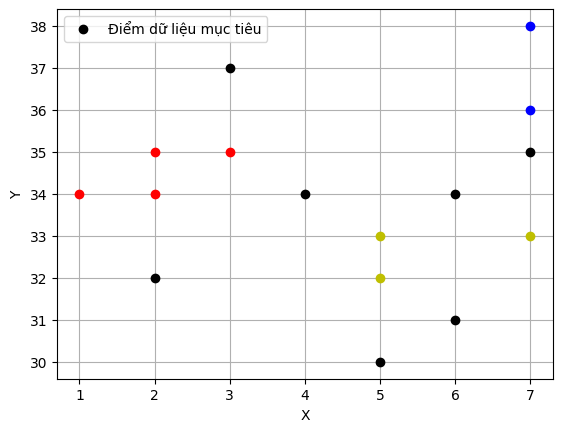

In [3]:
plt.plot(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], 'ro')
plt.plot(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], 'yo')
plt.plot(X_train[y_train == 2][:, 0], X_train[y_train == 2][:, 1], 'bo')
plt.plot(X_test[:, 0], X_test[:, 1], 'ko', label="Điểm dữ liệu mục tiêu")

plt.xlabel("X")
plt.ylabel("Y")

plt.legend()
plt.grid()
plt.show()

## Lớp `TreeNode` trong Decision Tree

### Mô tả

Lớp `TreeNode` đại diện cho một nút trong cây quyết định (Decision Tree). Mỗi nút trong cây quyết định có thể chứa thông tin về đặc trưng để chia (split feature), giá trị ngưỡng để chia (split value), nhánh con trái (left child), nhánh con phải (right child), và nhãn (label) nếu nút đó là nút lá.

### Các thành phần chính

- **split_feature**: Chỉ số của đặc trưng để chia tại nút này.
- **split_value**: Ngưỡng để quyết định chia nhánh trái hay phải.
- **left**: Con trỏ đến nút con bên trái.
- **right**: Con trỏ đến nút con bên phải.
- **label**: Nhãn của nút nếu nó là nút lá (leaf node).


In [4]:
class TreeNode:
    def __init__(self, split_feature=None, split_value=None, left=None, right=None, label=None):
        self.split_feature = split_feature
        self.split_value = split_value
        self.left = left
        self.right = right
        self.label = label

## DecisionTreeClassifier from Scratch

### Mô tả

Lớp `DecisionTreeClassifier` được thiết kế để triển khai thuật toán cây quyết định (Decision Tree). Thuật toán này được sử dụng để phân loại dữ liệu dựa trên các đặc trưng của nó. Cây quyết định hoạt động bằng cách chia dữ liệu thành các nhánh dựa trên các đặc trưng và giá trị ngưỡng, cho đến khi đạt điều kiện dừng.

### Các thành phần chính

#### 1. Khởi tạo lớp `DecisionTreeClassifier`

- **root**: Gốc của cây quyết định, khởi tạo ban đầu là `None`.
- **min_samples_split**: Số lượng mẫu tối thiểu để chia.
- **max_depth**: Độ sâu tối đa của cây.

#### 2. Phương thức `build_tree`

- Xây dựng cây quyết định từ dữ liệu huấn luyện `X` và nhãn `y`.
- Kiểm tra điều kiện dừng khi tất cả các nhãn trong `y` là giống nhau hoặc số lượng mẫu ít hơn `min_samples_split` hoặc đạt độ sâu tối đa `max_depth`.
- Tìm kiếm cách chia tốt nhất bằng phương thức `get_best_split`.

#### 3. Phương thức `get_best_split`

- Tìm kiếm cách chia tốt nhất bằng cách duyệt qua tất cả các đặc trưng và giá trị ngưỡng.
- Tính toán Gini impurity để đánh giá chất lượng của từng cách chia.

#### 4. Phương thức `split`

- Chia dữ liệu thành hai tập con dựa trên giá trị ngưỡng của một đặc trưng.

#### 5. Phương thức `evaluate_split`

- Đánh giá chất lượng của một cách chia bằng cách tính toán Gini impurity của hai tập con.

#### 6. Phương thức `gini_index`

- Tính toán Gini impurity cho một tập nhãn `y`.

#### 7. Phương thức `fit`

- Huấn luyện cây quyết định trên dữ liệu huấn luyện `X` và nhãn `y`.

#### 8. Phương thức `predict`

- Dự đoán nhãn cho các mẫu dữ liệu trong `X`.

#### 9. Phương thức `make_prediction`

- Dự đoán nhãn cho một mẫu dữ liệu `x` dựa trên cây quyết định.

In [5]:
class DecisionTreeClassifier:
    def __init__(self, min_samples_split=2, max_depth=float("inf")):
        self.root = None
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth

    def build_tree(self, X, y, depth=0):
        num_samples, _ = X.shape
        if len(np.unique(y)) == 1 or num_samples < self.min_samples_split or depth >= self.max_depth:
            return TreeNode(label=np.bincount(y).argmax())

        best_split = self.get_best_split(X, y)

        left_subtree = self.build_tree(**best_split["Xy_left"], depth=depth+1)
        right_subtree = self.build_tree(**best_split["Xy_right"], depth=depth+1)

        return TreeNode(
            split_feature=best_split["feature_index"],
            split_value=best_split["threshold"],
            left=left_subtree,
            right=right_subtree
        )

    def get_best_split(self, X, y):
        _, num_features = X.shape
        best_split = {}
        best_gini = float("inf")

        for feature_index in range(num_features):
            feature_values = np.sort(np.unique(X[:, feature_index]))

            for i in range(len(feature_values) - 1):
                threshold = (feature_values[i] + feature_values[i + 1]) / 2
                Xy_left, Xy_right = self.split(X, y, feature_index, threshold).values()
                

                if len(Xy_left["X"]) > 0 and len(Xy_right["X"]) > 0:
                    current_gini = self.evaluate_split(len(y), Xy_left["y"], Xy_right["y"])
                    if current_gini < best_gini:
                        best_split["feature_index"] = feature_index
                        best_split["threshold"] = threshold
                        best_split["Xy_left"] = Xy_left
                        best_split["Xy_right"] = Xy_right
                        best_gini = current_gini

        return best_split

    def split(self, X, y, feature_index, threshold):
        left_mask = X[:, feature_index] <= threshold
        right_mask = X[:, feature_index] > threshold
        return {
            "Xy_left": {"X": X[left_mask], "y": y[left_mask]},
            "Xy_right": {"X": X[right_mask], "y": y[right_mask]}
        }

    def evaluate_split(self, num_samples, y_left, y_right):
        weight_left = len(y_left) / num_samples
        weight_right = len(y_right) / num_samples
        return weight_left * self.gini_index(y_left) + weight_right * self.gini_index(y_right)

    def gini_index(self, y):
        labels = np.unique(y)
        gini = 1.0
        for label in labels:
            p = np.sum(y == label) / len(y)
            gini -= p ** 2
        return gini

    def fit(self, X, y):
        self.root = self.build_tree(X, y)
        return self

    def predict(self, X):
        return np.array([self.make_prediction(x, self.root) for x in X])

    def make_prediction(self, x, node):
        if node.label is not None:
            return node.label
        if x[node.split_feature] <= node.split_value:
            return self.make_prediction(x, node.left)
        else:
            return self.make_prediction(x, node.right)

In [6]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

In [7]:
clf.predict(X_test)

array([1, 0, 1, 1, 2, 0, 0])

## DecisionTreeClassifier from `sklearn`

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
clf.predict(X_test)

array([1, 0, 1, 1, 2, 0, 0])

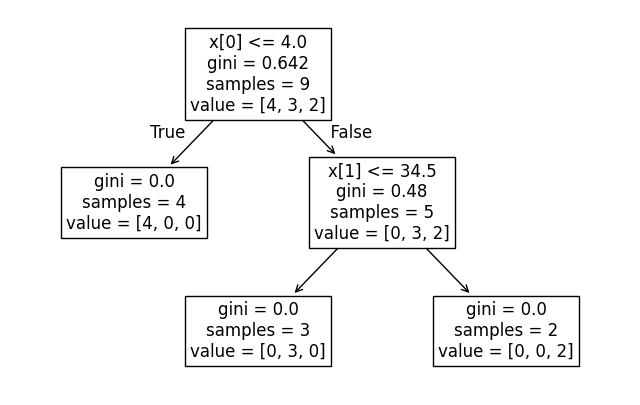

In [10]:
plt.figure(figsize=(8, 5))
tree.plot_tree(clf, fontsize=12)
plt.show()

# Decision Tree Regression

## Mô tả

Decision Tree Regression là một biến thể của thuật toán cây quyết định, được sử dụng để giải quyết các bài toán hồi quy. Thay vì phân loại dữ liệu thành các lớp như trong Decision Tree Classification, Decision Tree Regression dự đoán các giá trị liên tục.

## Cách hoạt động

Decision Tree Regression hoạt động bằng cách chia không gian đặc trưng thành các vùng và gán giá trị dự đoán là giá trị trung bình của các điểm dữ liệu trong mỗi vùng. Các bước chính bao gồm:

1. **Chọn đặc trưng và giá trị ngưỡng để chia dữ liệu**:
   - Chọn đặc trưng và giá trị ngưỡng (threshold) sao cho chia dữ liệu thành hai tập con với tổng sai số (error) nhỏ nhất.
   - Sai số thường được đo bằng các chỉ số như Mean Squared Error (MSE) hoặc Mean Absolute Error (MAE).

2. **Chia dữ liệu**:
   - Chia dữ liệu thành hai tập con dựa trên giá trị ngưỡng đã chọn.

3. **Lặp lại quá trình**:
   - Lặp lại quá trình chia dữ liệu cho đến khi đạt điều kiện dừng, chẳng hạn như:
     - Độ sâu của cây đạt mức tối đa.
     - Số lượng mẫu trong một nút nhỏ hơn giá trị tối thiểu.

4. **Gán giá trị dự đoán**:
   - Giá trị dự đoán của một nút là giá trị trung bình của các giá trị đầu ra trong tập con tương ứng.

## Ưu điểm và nhược điểm

### Ưu điểm:
- **Dễ hiểu và trực quan**: Cây quyết định dễ hiểu và có thể được trực quan hóa để giải thích các quyết định.
- **Không cần chuẩn hóa dữ liệu**: Decision Tree Regression không yêu cầu chuẩn hóa dữ liệu hoặc biến đổi đặc trưng.
- **Xử lý được dữ liệu phi tuyến**: Có thể xử lý tốt các quan hệ phi tuyến giữa các đặc trưng.

### Nhược điểm:
- **Dễ bị overfitting**: Decision Tree Regression dễ bị overfitting nếu không có cơ chế dừng phù hợp (ví dụ: độ sâu tối đa của cây, số lượng mẫu tối thiểu).
- **Không ổn định**: Một thay đổi nhỏ trong dữ liệu có thể dẫn đến cây hoàn toàn khác nhau.
- **Không tốt cho dự đoán ngoại suy**: Cây quyết định không dự đoán tốt cho các giá trị nằm ngoài phạm vi của dữ liệu huấn luyện.


## Dữ liệu thử nghiệm

In [11]:
X_train = np.array([[1], [2], [3], [3], [4], [5], [6], [7]])
y_train = np.array([1, 1, 1, 2, 5, 9, 9, 9])
X_test = np.array([[3], [4], [5]])

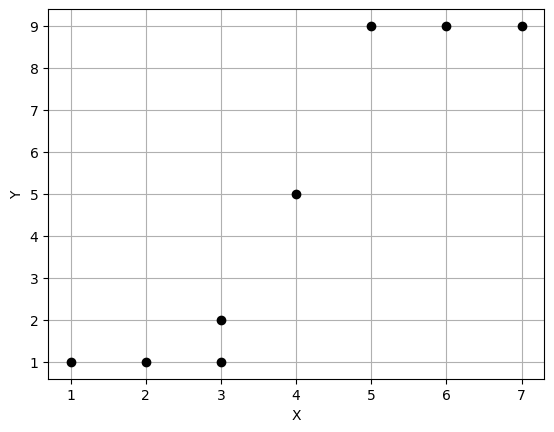

In [12]:
plt.plot(X_train.reshape(-1), y_train, 'ko')

plt.xlabel("X")
plt.ylabel("Y")

plt.grid()
plt.show()

## Decision Tree Regression

### Mô tả

Decision Tree Regression là một thuật toán học máy dùng để giải quyết các bài toán hồi quy. Thay vì phân loại dữ liệu thành các lớp, Decision Tree Regression dự đoán các giá trị liên tục. Cây quyết định hồi quy hoạt động bằng cách chia không gian đặc trưng thành các vùng dựa trên các giá trị ngưỡng của đặc trưng, sau đó gán giá trị dự đoán là giá trị trung bình của các điểm dữ liệu trong mỗi vùng.

### Các thành phần chính

#### 1. Khởi tạo lớp `DecisionTreeRegressor`

- **root**: Gốc của cây quyết định, khởi tạo ban đầu là `None`.
- **max_depth**: Độ sâu tối đa của cây.
- **min_samples_split**: Số lượng mẫu tối thiểu để chia.

#### 2. Phương thức `build_tree`

- Xây dựng cây quyết định từ dữ liệu huấn luyện `X` và nhãn `y`.
- Kiểm tra điều kiện dừng khi độ sâu của cây đạt mức tối đa, số lượng mẫu nhỏ hơn `min_samples_split` hoặc khi chỉ còn một mẫu dữ liệu.
- Tìm kiếm cách chia tốt nhất bằng phương thức `get_best_split`.

#### 3. Phương thức `get_best_split`

- Tìm kiếm cách chia tốt nhất bằng cách duyệt qua tất cả các đặc trưng và giá trị ngưỡng.
- Tính toán tổng bình phương sai số (RSS) để đánh giá chất lượng của từng cách chia.

#### 4. Phương thức `split`

- Chia dữ liệu thành hai tập con dựa trên giá trị ngưỡng của một đặc trưng.

#### 5. Phương thức `evaluate_split`

- Đánh giá chất lượng của một cách chia bằng cách tính toán tổng bình phương sai số của hai tập con.

#### 6. Phương thức `rss`

- Tính toán tổng bình phương sai số cho một tập nhãn `y`.

#### 7. Phương thức `fit`

- Huấn luyện cây quyết định hồi quy trên dữ liệu huấn luyện `X` và nhãn `y`.

#### 8. Phương thức `predict`

- Dự đoán giá trị cho các mẫu dữ liệu trong `X`.

#### 9. Phương thức `make_prediction`

- Dự đoán giá trị cho một mẫu dữ liệu `x` dựa trên cây quyết định.

In [13]:
class DecisionTreeRegressor:
    def __init__(self, max_depth, min_samples_split=2):
        self.root = None
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    def build_tree(self, X, y, depth=0):
        num_samples = len(y)
        if depth >= self.max_depth or num_samples < self.min_samples_split:
            return TreeNode(label=np.mean(y))

        best_split = self.get_best_split(X, y)
        if len(best_split) == 0:
            return TreeNode(label=np.mean(y))

        left_subtree = self.build_tree(**best_split["Xy_left"], depth=depth + 1)
        right_subtree = self.build_tree(**best_split["Xy_right"], depth=depth + 1)

        return TreeNode(
            split_feature=best_split["feature_index"],
            split_value=best_split["threshold"],
            left=left_subtree,
            right=right_subtree
        )

    def get_best_split(self, X, y):
        num_samples, num_features = X.shape

        best_split = {}
        best_rss = float("inf")

        for feature_index in range(num_features):
            feature_values = np.sort(np.unique(X[:, feature_index]))

            for i in range(len(feature_values) - 1):
                threshold = (feature_values[i] + feature_values[i + 1]) / 2
                Xy_left, Xy_right = self.split(X, y, feature_index, threshold).values()

                if len(Xy_left["X"]) > 0 and len(Xy_right["X"]) > 0:
                    current_rss = self.evaluate_split(len(y), Xy_left["y"], Xy_right["y"])
                    if current_rss < best_rss:
                        best_split["feature_index"] = feature_index
                        best_split["threshold"] = threshold
                        best_split["Xy_left"] = Xy_left
                        best_split["Xy_right"] = Xy_right
                        best_rss = current_rss

        return best_split

    def split(self, X, y, feature_index, threshold):
        left_mask = X[:, feature_index] <= threshold
        right_mask = X[:, feature_index] > threshold
        return {
            "Xy_left": {"X": X[left_mask], "y": y[left_mask]},
            "Xy_right": {"X": X[right_mask], "y": y[right_mask]}
        }

    def evaluate_split(self, num_samples, y_left, y_right):
        weight_left = len(y_left) / num_samples
        weight_right = len(y_right) / num_samples
        return weight_left * self.rss(y_left) + weight_right * self.rss(y_right)

    def rss(self, y):
        return np.mean((y - np.mean(y))**2)

    def fit(self, X, y):
        self.root = self.build_tree(X, y)
        return self

    def predict(self, X):
        return np.array([self.make_prediction(x, self.root) for x in X])

    def make_prediction(self, x, node):
        if node.label is not None:
            return node.label
        if x[node.split_feature] <= node.split_value:
            return self.make_prediction(x, node.left)
        else:
            return self.make_prediction(x, node.right)


In [14]:
reg = DecisionTreeRegressor(max_depth=1)
reg.fit(X_train, y_train)

In [15]:
reg.predict(X_test)

array([2., 2., 9.])

## DecisionTreeRegressor from `sklearn`

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

reg = DecisionTreeRegressor(max_depth=1)
reg.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [17]:
reg.predict(X_test)

array([2., 2., 9.])

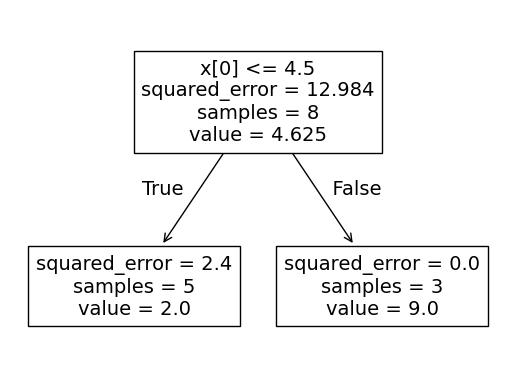

In [18]:
tree.plot_tree(reg)
plt.show()